In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('weight_experiment_df.csv')

In [2]:
df.weight_param.value_counts()

weight_param
0.5     4500
2.0     3000
6.0     3000
10.0    3000
Name: count, dtype: int64

In [3]:
def tail_share(weights, tail_indices, p_init=1/3):
    W = sum(weights)
    W_tail = sum(weights[tail_indices:])
    return p_init * W_tail / W  # доля в общей популяции


print('Deepseek Chat')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [1] * 9, tail_indices=7) / 0.33 )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 9, tail_indices=7) / 0.33)


print('Reasoner')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 5, tail_indices=7) )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 5, tail_indices=7)  )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 5, tail_indices=7) )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 5, tail_indices=7) )


Deepseek Chat
0.0967741935483871 0.29325513196480935
0.20689655172413793 0.45454545454545453
0.27692307692307694 0.8116883116883117
0.297029702970297 0.9000900090009
Reasoner
0.06172839506172839
0.15873015873015872
0.24390243902439024
0.27322404371584696


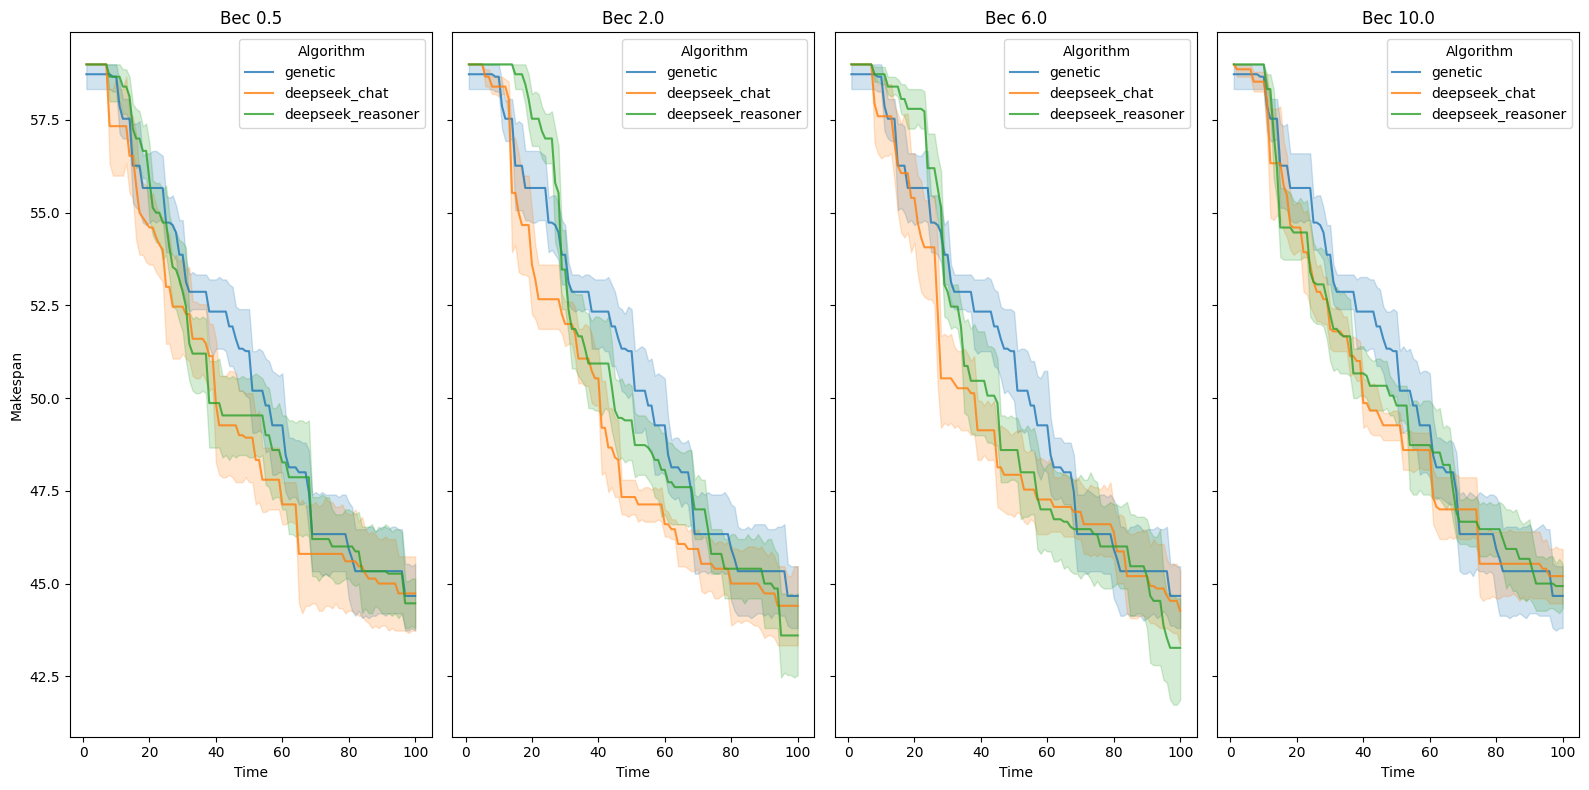

In [4]:
_, axes = plt.subplots(*(1,4), figsize=(16,8), sharey=True)


df = pd.read_csv('weight_experiment_df.csv')

sns.lineplot(df.query('weight_param == 0.5 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[0])


sns.lineplot(df.query('weight_param == 2.0 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[1])


sns.lineplot(df.query('weight_param == 6.0 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
            estimator='mean', alpha=0.8, ax = axes[2])


sns.lineplot(df.query('weight_param == 10.0 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
             estimator='mean', alpha=0.8, ax = axes[3])


for ax, w in zip(axes, (0.5, 2.0, 6.0, 10.0)):
    ax.set_title(f'Вес {w}')

plt.tight_layout()
    

#  units='run', estimator=None

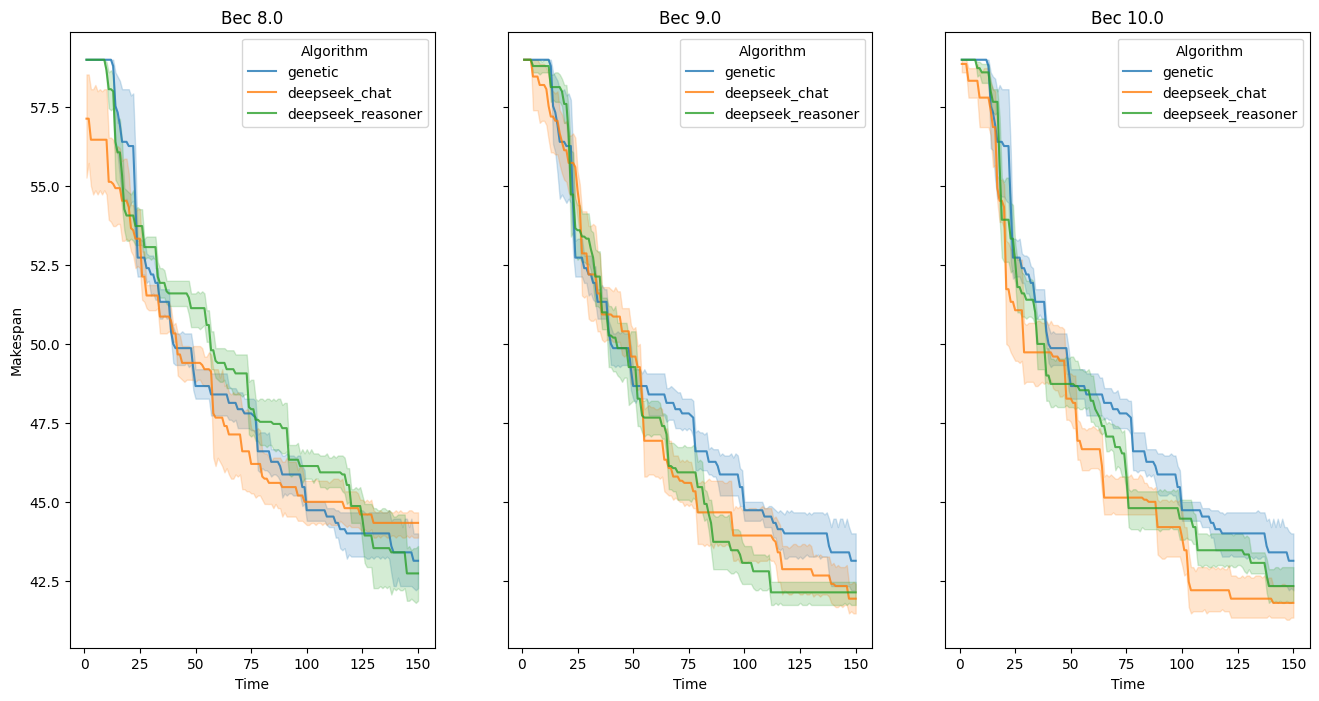

In [5]:
df = pd.read_csv('weight_experiment2_df.csv')

_, axes = plt.subplots(*(1,3), figsize=(16,8), sharey=True)



sns.lineplot(df.query('weight_param == 8.0 or Algorithm == "genetic" '),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[0])


sns.lineplot(df.query('weight_param == 9.0 or Algorithm == "genetic" '),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[1])


sns.lineplot(df.query('weight_param == 10.0 or Algorithm == "genetic" '),
              x='Time', y='Makespan', hue='Algorithm', 
            estimator='mean', alpha=0.8, ax = axes[2])


for ax, w in zip(axes, (8.0, 9.0, 10.0)):
    ax.set_title(f'Вес {w}')


# sns.lineplot(df.query('weight_param == 10.0'),
#               x='Time', y='Makespan', hue='Algorithm', 
#              estimator='mean', alpha=0.8, ax = axes[3])

#  units='run', estimator=None

In [6]:
df.groupby('Algorithm').Makespan.min()

Algorithm
deepseek_chat        41.0
deepseek_reasoner    40.0
genetic              41.0
Name: Makespan, dtype: float64

# Эксперимент с % эвристик в популяции

<Axes: xlabel='Time', ylabel='Makespan'>

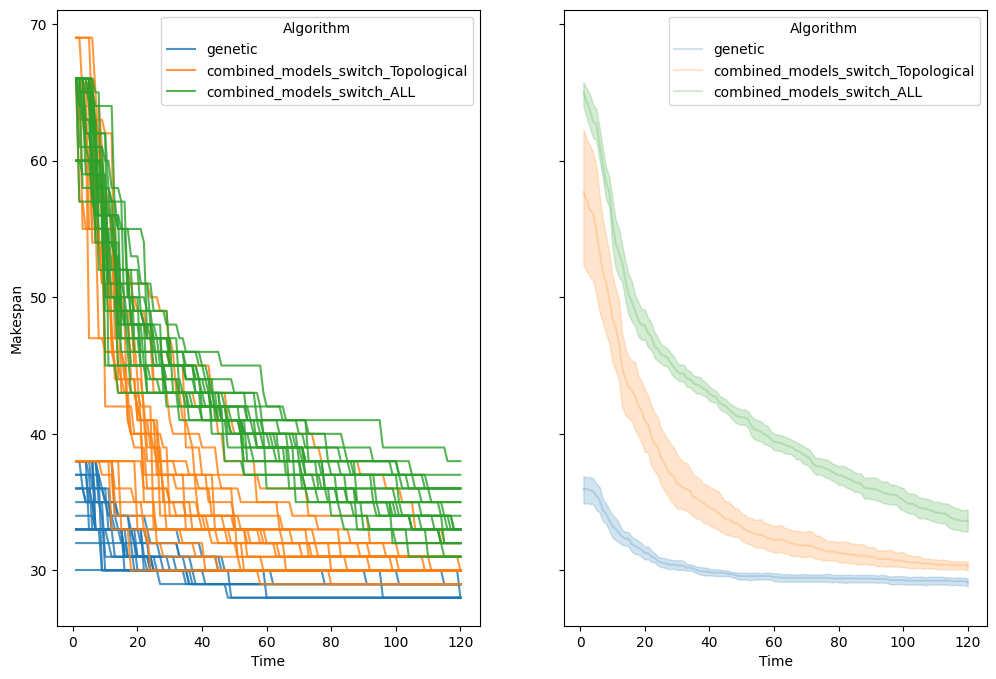

In [8]:
res_j50_df = pd.read_csv('0_res_j50_dfs.csv')
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


_, axes = plt.subplots(*(1,2), figsize=(12,8), sharey=True)


axes = axes.flatten()

sns.lineplot( data = res_j50_df,
              x='Time', y='Makespan', hue='Algorithm', 
              units='run',
              estimator=None, alpha=0.8, ax = axes[0])


sns.lineplot( data = res_j50_df,
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.2, ax = axes[1])




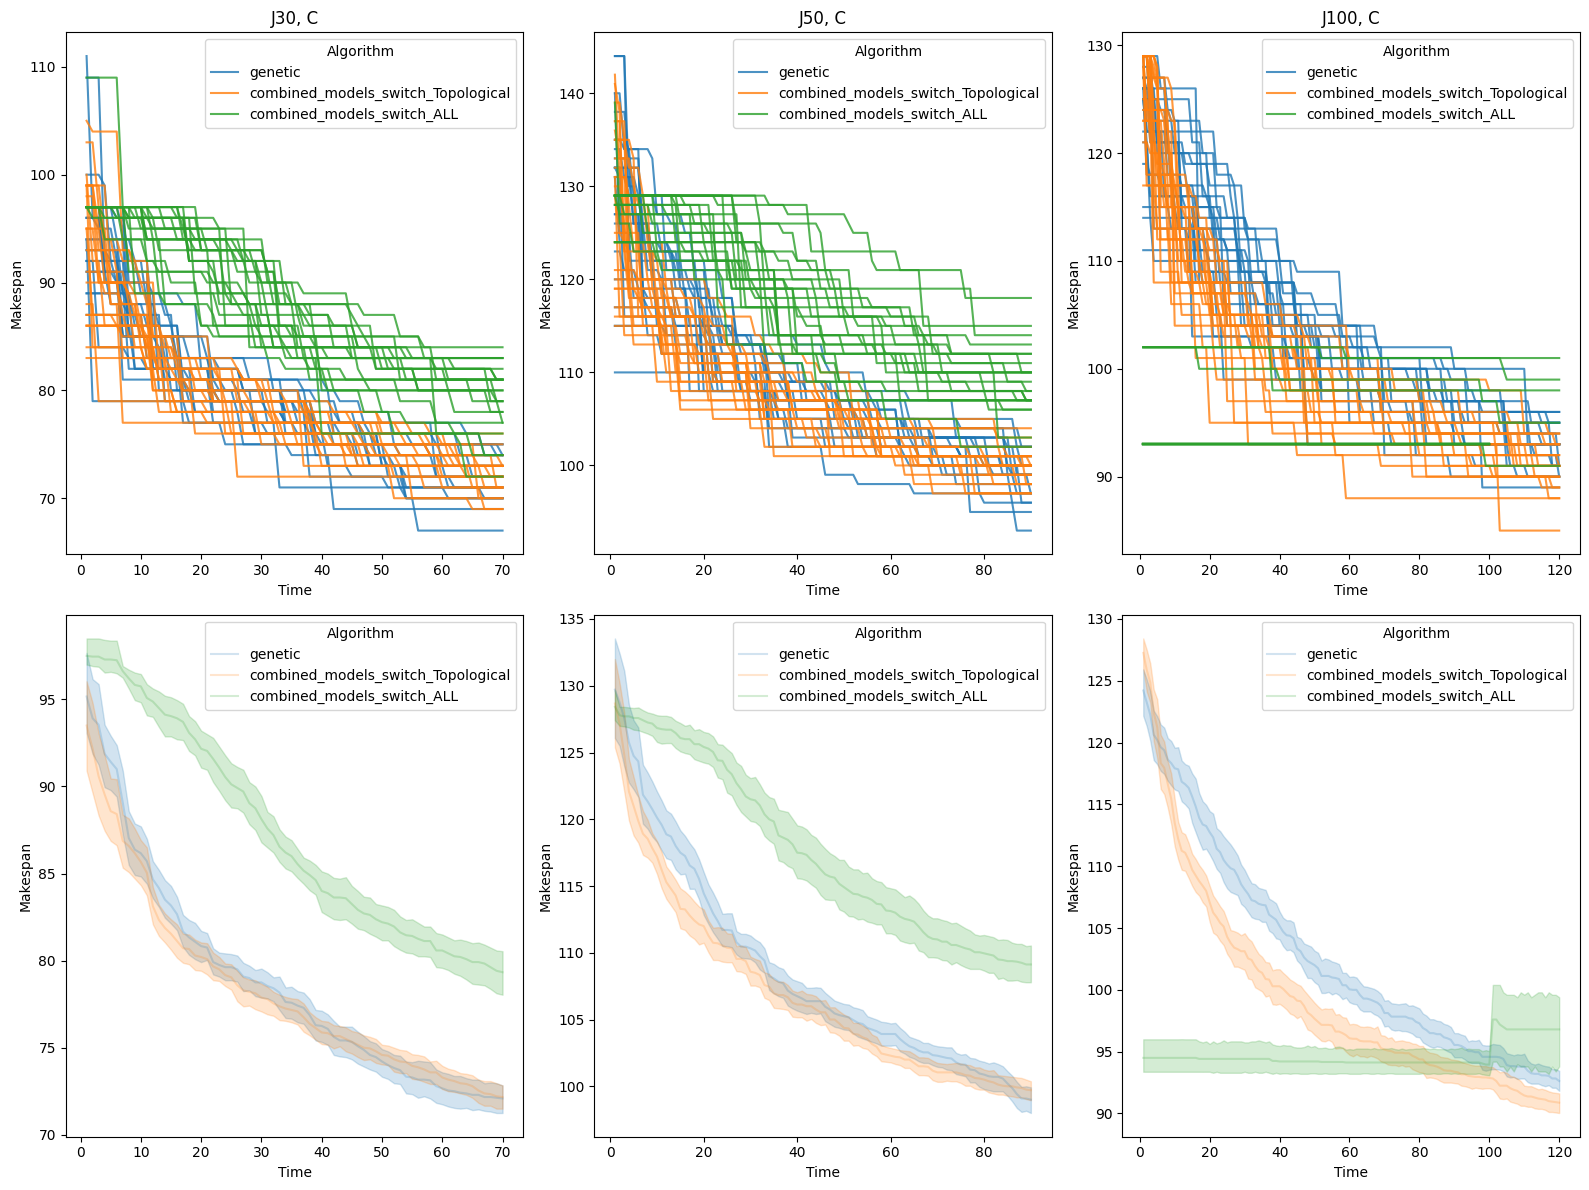

In [9]:
runs = {'J30, C' : '3_res_j30_dfs.csv', 
        'J50, C' : '3_res_j50_dfs.csv', 
        'J100, C': '3_res_j100_dfs.csv'}
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
_, axes = plt.subplots(*(2, 3), figsize=(16, 12), sharey=False)
axes = axes.flatten()
i = 0
for name, run in runs.items():
    df = pd.read_csv(os.path.join('Experiments/Runs', run))
    sns.lineplot( data = df,
                x='Time', y='Makespan', hue='Algorithm', 
                units='run',
                estimator=None, alpha=0.8, ax = axes[i])
    axes[i].set_title(name)
    sns.lineplot( data = df,
                x='Time', y='Makespan', hue='Algorithm', 
                estimator='mean', alpha=0.2, ax = axes[i+3])

    # last_generation = df.Makespan.max()
    # sns.boxplot(data = df.query('Makespan == @last_generation'),
    #             x='Algorithm', y='Makespan', ax = axes[i+6])
    i+=1
plt.tight_layout()

In [10]:
def plot_iter(df, ax, hue = 'Algorithm'):
    sns.lineplot(data = df,
             x='Time', y='Makespan', hue=hue, 
             units='run',
             estimator=None,
             alpha=0.8, ax = ax)
    sns.move_legend(ax, 'upper right',)

def plot_smooth_iter(df, ax,  hue = 'Algorithm'):
    sns.lineplot(data = df,
             x='Time', y='Makespan', hue=hue, 
             estimator='mean',
             alpha=0.8, ax = ax)
    sns.move_legend(ax, 'upper right',)

combined_models_switch_Topological
combined_models_switch_ALL
combined_models_switch_LFTrand
combined_models_switch_HEFT
combined_models_add_with_HEFT


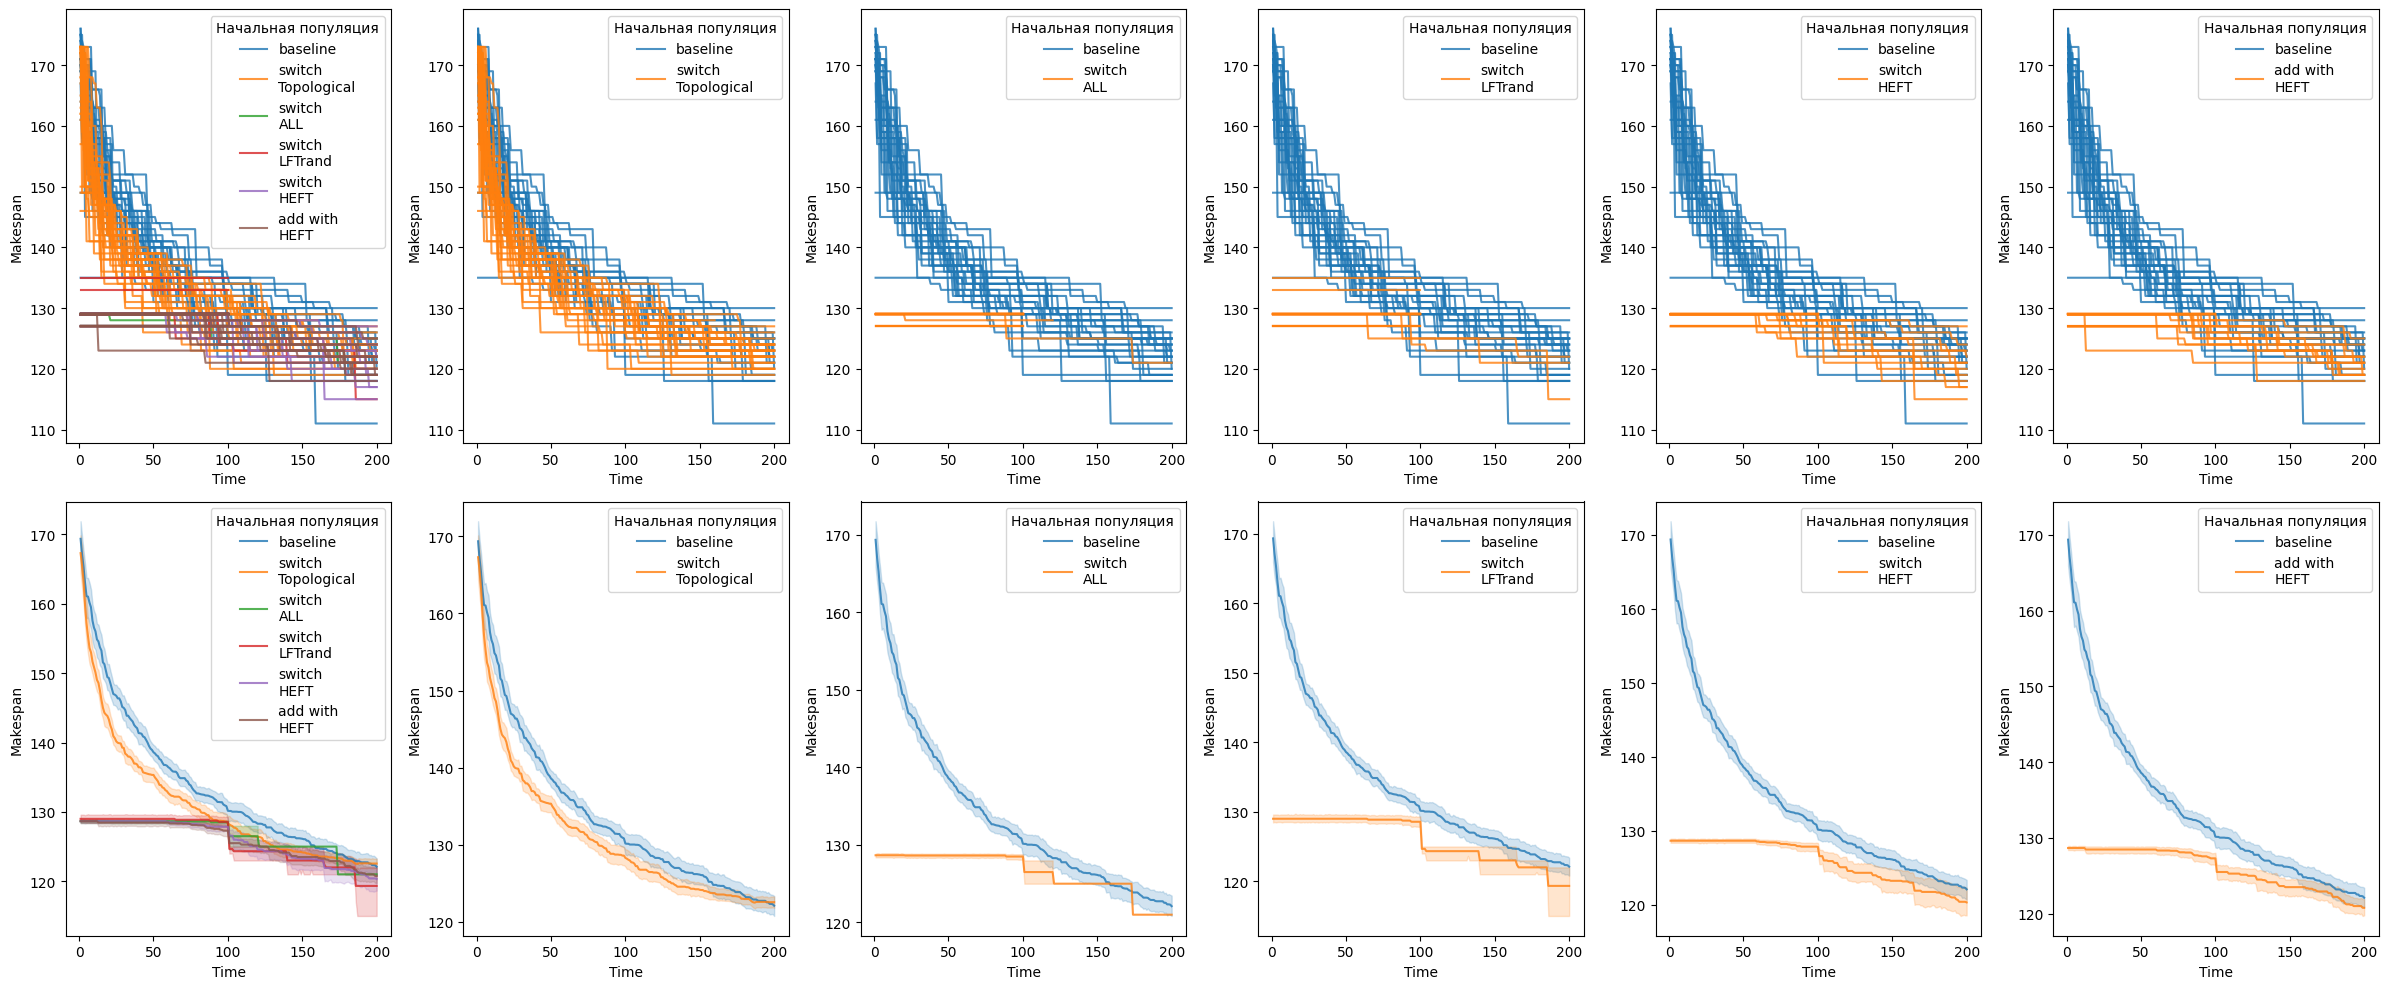

In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(*(2, 6), figsize=(24, 10), sharey=False)
axes = axes.flatten()
i = 0


run = 'final_j100.csv'
df = pd.read_csv(os.path.join('Experiments/Runs', run))

name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
}


df['Начальная популяция'] = df['Algorithm'].map(name_map)

plot_iter(df, axes[i],  'Начальная популяция')
plot_smooth_iter(df, axes[i+6], 'Начальная популяция')

i += 1
for algo in df[df.Algorithm != 'genetic']['Algorithm'].unique():
    print(algo)
    mode_df = df[df.Algorithm.isin([algo, 'genetic'])]
    plot_iter(mode_df, axes[i], 'Начальная популяция')
    plot_smooth_iter(mode_df, axes[i+6], 'Начальная популяция')
    i += 1
    
plt.tight_layout()

In [12]:
from scipy.stats import t
import numpy as np

index = ['baseline', 
        'add with\nHEFT',
         'switch\nTopological', 
         'switch\nLFTrand', 
         'switch\nHEFT',
         'switch\nALL',]

res = (
    df.query('Time == 200')
      .groupby('Начальная популяция')['Makespan']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.9
res['se'] = res['std'] / np.sqrt(res['count'])
res['t_crit'] = t.ppf(1 - alpha/2, df=res['count'] - 1)
res['ci_low'] = round(res['mean'] - res['t_crit'] * res['se'],1)
res['ci_high'] = round(res['mean'] + res['t_crit'] * res['se'],1)

res.loc[index]

,mean,std,count,se,t_crit,ci_low,ci_high
Начальная популяция,,,,,,,
baseline,122.100000,3.632706,30,0.663238,0.126767,122.0,122.2
add with\nHEFT,120.769231,2.087816,13,0.579056,0.128347,120.7,120.8
switch\nTopological,122.555556,1.908147,27,0.367223,0.126895,122.5,122.6
switch\nLFTrand,119.333333,3.785939,3,2.185813,0.142134,119.0,119.6
switch\nHEFT,120.333333,3.393398,12,0.979590,0.128594,120.2,120.5
switch\nALL,121.000000,NaN,1,NaN,NaN,NaN,NaN


In [13]:
last_epoch = df.query('Time == 200')
last_epoch.reset_index(inplace=True)
baseline = last_epoch.query('`Начальная популяция` == "baseline"')['Makespan'].min()
last_epoch['better'] = np.where( df.query('Time == 200')['Makespan'] < baseline, 1, 0)

last_epoch

/var/folders/g_/4txfl8x17kv9txsffh9p9xf00000gn/T/ipykernel_21163/67464958.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_epoch['better'] = np.where( df.query('Time == 200')['Makespan'] < baseline, 1, 0)


,index,Unnamed: 0,Makespan,Time,run,Algorithm,Начальная популяция,better
0,199,199,124.0,200,1,genetic,baseline,0
1,399,199,123.0,200,2,genetic,baseline,0
2,599,199,122.0,200,3,genetic,baseline,0
3,799,199,128.0,200,4,genetic,baseline,0
4,999,199,111.0,200,5,genetic,baseline,0
...,...,...,...,...,...,...,...,...
81,25847,199,119.0,200,24,combined_models_add_with_HEFT,add with\nHEFT,0
82,26047,199,119.0,200,25,combined_models_add_with_HEFT,add with\nHEFT,0
83,26247,199,121.0,200,26,combined_models_add_with_HEFT,add with\nHEFT,0
84,26547,199,121.0,200,28,combined_models_add_with_HEFT,add with\nHEFT,0


In [14]:
last_epoch.groupby('Начальная популяция').better.mean() * 100

Начальная популяция
add with\nHEFT         0.0
baseline               0.0
switch\nALL            0.0
switch\nHEFT           0.0
switch\nLFTrand        0.0
switch\nTopological    0.0
Name: better, dtype: float64

In [15]:
last_epoch['gap'] = (pd.merge(
    last_epoch,
    last_epoch.query('`Начальная популяция` == "baseline"')[['run','Makespan']],
    on='run',
    how='left',
    suffixes=('', '_baseline'))\
    .apply(lambda x: (x['Makespan_baseline'] - x['Makespan']) * 100/ x['Makespan_baseline'], axis=1)
 )
#max((x['Makespan_baseline'] - x['Makespan']) / x['Makespan_baseline'], 0)

/var/folders/g_/4txfl8x17kv9txsffh9p9xf00000gn/T/ipykernel_21163/3242564962.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_epoch['gap'] = (pd.merge(


In [16]:
index = ['baseline', 
        'add with\nHEFT',
         'switch\nTopological', 
         'switch\nLFTrand', 
         'switch\nHEFT',
         'switch\nALL',]

res_gap = (
    last_epoch
      .groupby('Начальная популяция')['gap']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.9
res_gap['se'] = res_gap['std'] / np.sqrt(res['count'])
res_gap['t_crit'] = t.ppf(1 - alpha/2, df=res_gap['count'] - 1)
res_gap['ci_low'] = round(res_gap['mean'] - res_gap['t_crit'] * res_gap['se'],1)
res_gap['ci_high'] = round(res_gap['mean'] + res_gap['t_crit'] * res_gap['se'],1)

res_gap[['mean', 'ci_low', 'ci_high']].loc[index].apply(lambda x: print(str(round(x['mean'],1)) + '\n' + str(x['ci_low']) + '-' + str(x['ci_high'])), axis=1 )

0.0
0.0-0.0
0.9
0.7-1.0
-0.6
-0.7--0.5
2.7
2.3-3.0
1.5
1.4-1.7
3.2
nan-nan


Начальная популяция
baseline               None
add with\nHEFT         None
switch\nTopological    None
switch\nLFTrand        None
switch\nHEFT           None
switch\nALL            None
dtype: object

# J50

combined_models_switch_Topological
combined_models_switch_ALL
combined_models_switch_LFTrand
combined_models_switch_HEFT
combined_models_add_with_HEFT


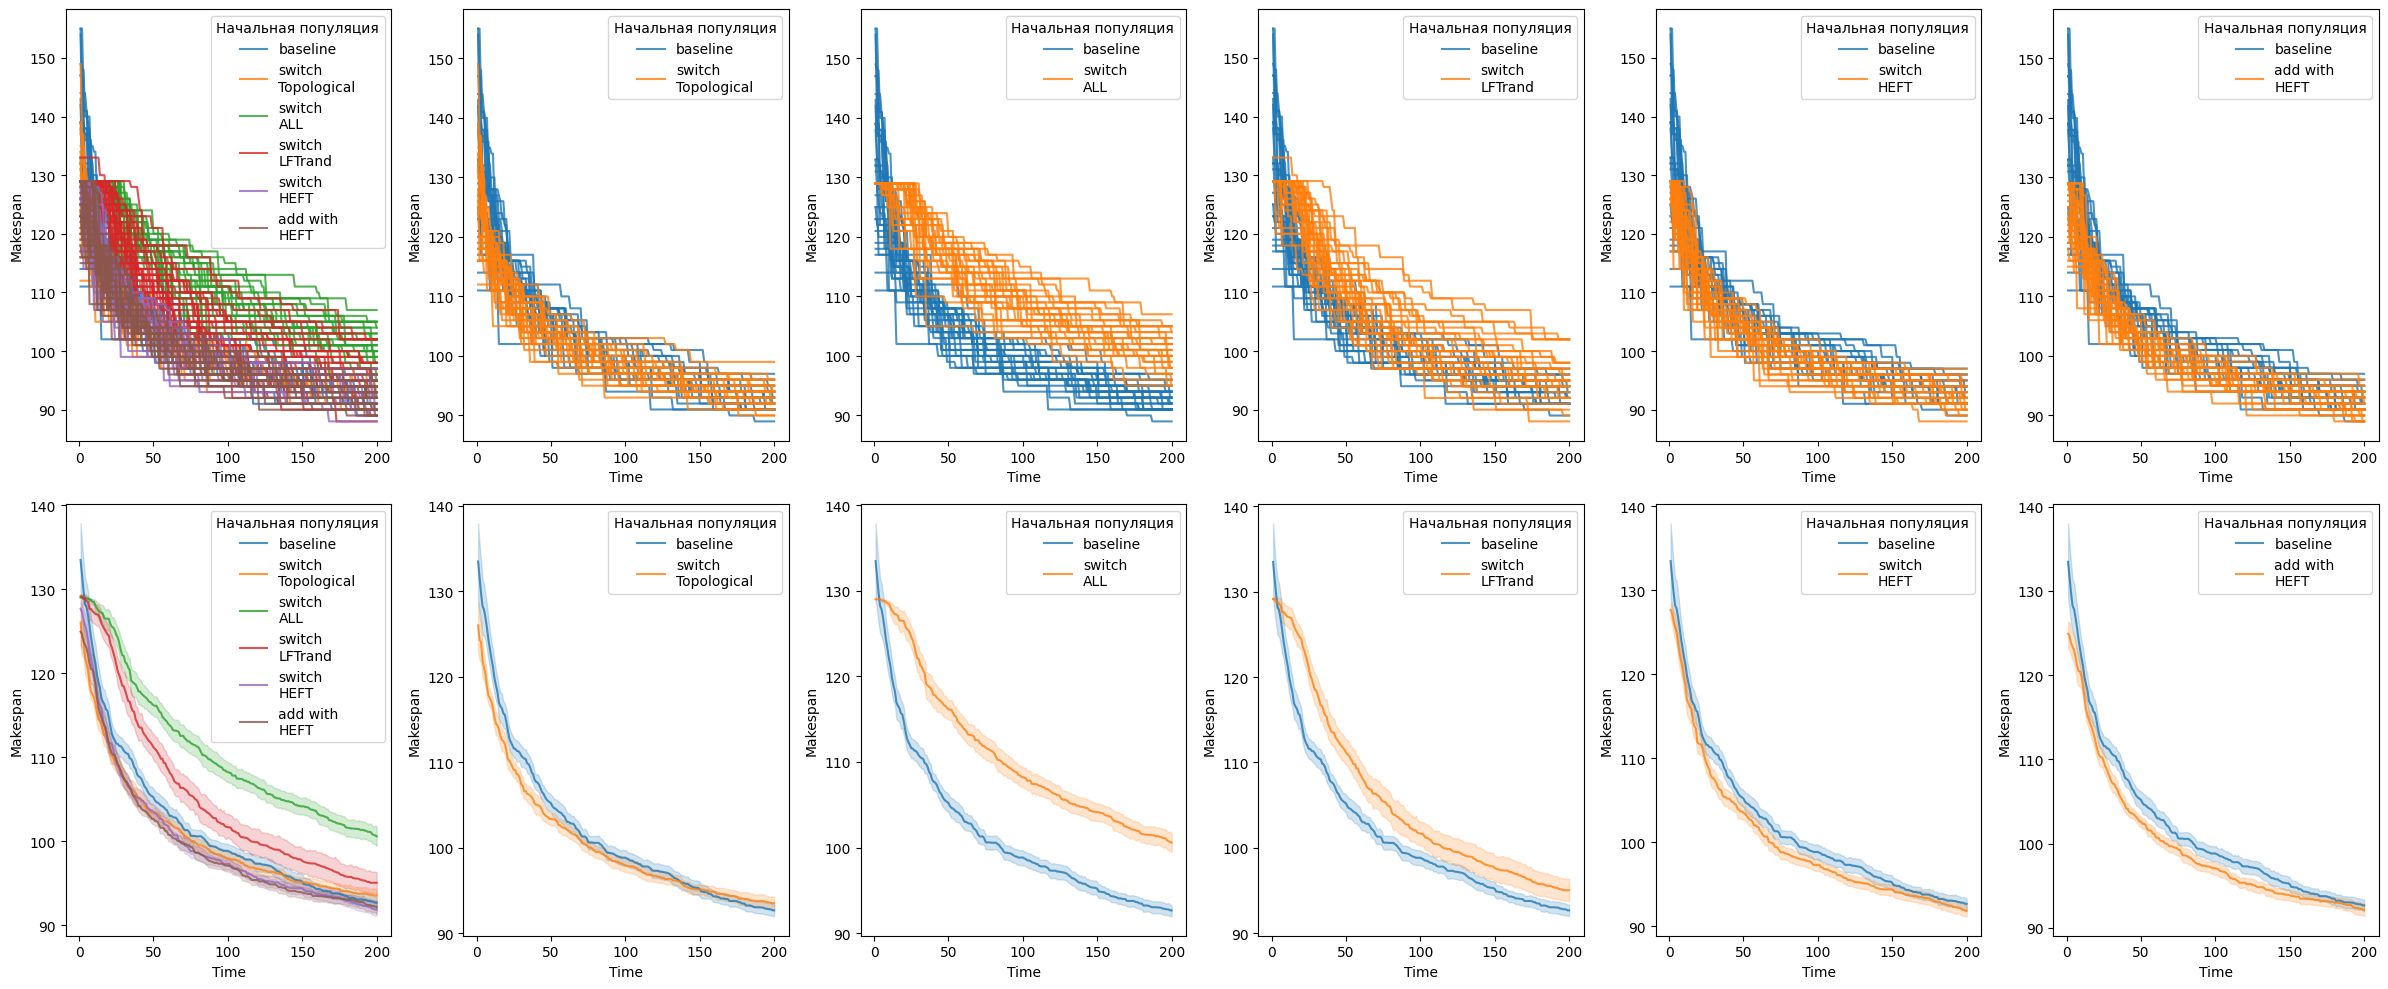

In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(*(2, 6), figsize=(24, 10), sharey=False)
axes = axes.flatten()
i = 0


run = 'final_j50.csv'
df = pd.read_csv(os.path.join('Experiments/Runs', run))

name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
}


df['Начальная популяция'] = df['Algorithm'].map(name_map)

plot_iter(df, axes[i],  'Начальная популяция')
plot_smooth_iter(df, axes[i+6], 'Начальная популяция')

i += 1
for algo in df[df.Algorithm != 'genetic']['Algorithm'].unique():
    print(algo)
    mode_df = df[df.Algorithm.isin([algo, 'genetic'])]
    plot_iter(mode_df, axes[i], 'Начальная популяция')
    plot_smooth_iter(mode_df, axes[i+6], 'Начальная популяция')
    i += 1
    
plt.tight_layout()

In [18]:
from scipy.stats import t
import numpy as np

index = ['baseline', 
        'add with\nHEFT',
         'switch\nTopological', 
         'switch\nLFTrand', 
         'switch\nHEFT',
         'switch\nALL',]


run = 'final_j50.csv'
df = pd.read_csv(os.path.join('Experiments/Runs', run))
name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
}


df['Начальная популяция'] = df['Algorithm'].map(name_map)

res = (
    df.query('Time == 200')
      .groupby('Начальная популяция')['Makespan']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.9
res['se'] = res['std'] / np.sqrt(res['count'])
res['t_crit'] = t.ppf(1 - alpha/2, df=res['count'] - 1)
res['ci_low'] = round(res['mean'] - res['t_crit'] * res['se'],2)
res['ci_high'] = round(res['mean'] + res['t_crit'] * res['se'],2)

res.loc[index]

,mean,std,count,se,t_crit,ci_low,ci_high
Начальная популяция,,,,,,,
baseline,92.666667,1.899788,30,0.346852,0.126767,92.62,92.71
add with\nHEFT,92.133333,2.046584,30,0.373653,0.126767,92.09,92.18
switch\nTopological,93.500000,2.009238,28,0.379710,0.126849,93.45,93.55
switch\nLFTrand,95.033333,3.727654,30,0.680573,0.126767,94.95,95.12
switch\nHEFT,91.833333,2.052473,30,0.374729,0.126767,91.79,91.88
switch\nALL,100.566667,3.202190,30,0.584637,0.126767,100.49,100.64


In [19]:
last_epoch = df.query('Time == 200')
last_epoch.reset_index(inplace=True)
baseline = last_epoch.query('`Начальная популяция` == "baseline"')['Makespan'].min()
last_epoch['better'] = np.where( df.query('Time == 200')['Makespan'] < baseline, 1, 0)

last_epoch

/var/folders/g_/4txfl8x17kv9txsffh9p9xf00000gn/T/ipykernel_21163/67464958.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_epoch['better'] = np.where( df.query('Time == 200')['Makespan'] < baseline, 1, 0)


,index,Unnamed: 0,Makespan,Time,run,Algorithm,Начальная популяция,better
0,199,199,93.0,200,1,genetic,baseline,0
1,399,199,95.0,200,2,genetic,baseline,0
2,599,199,94.0,200,3,genetic,baseline,0
3,799,199,93.0,200,4,genetic,baseline,0
4,999,199,91.0,200,5,genetic,baseline,0
...,...,...,...,...,...,...,...,...
173,35144,199,90.0,200,26,combined_models_add_with_HEFT,add with\nHEFT,0
174,35344,199,91.0,200,27,combined_models_add_with_HEFT,add with\nHEFT,0
175,35544,199,95.0,200,28,combined_models_add_with_HEFT,add with\nHEFT,0
176,35744,199,94.0,200,29,combined_models_add_with_HEFT,add with\nHEFT,0


In [20]:
last_epoch['gap'] = (pd.merge(
    last_epoch,
    last_epoch.query('`Начальная популяция` == "baseline"')[['run','Makespan']],
    on='run',
    how='left',
    suffixes=('', '_baseline'))\
    .apply(lambda x: (x['Makespan_baseline'] - x['Makespan']) * 100/ x['Makespan_baseline'], axis=1)
 )
#max((x['Makespan_baseline'] - x['Makespan']) / x['Makespan_baseline'], 0)

/var/folders/g_/4txfl8x17kv9txsffh9p9xf00000gn/T/ipykernel_21163/3242564962.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_epoch['gap'] = (pd.merge(


In [21]:
last_epoch.groupby('Начальная популяция').better.mean() * 100

Начальная популяция
add with\nHEFT         0.000000
baseline               0.000000
switch\nALL            0.000000
switch\nHEFT           3.333333
switch\nLFTrand        3.333333
switch\nTopological    0.000000
Name: better, dtype: float64

In [22]:
index = ['baseline', 
         'add with\nHEFT',
         'switch\nTopological', 

         'switch\nLFTrand', 
         'switch\nHEFT',
                  'switch\nALL',]

res_gap = (
    last_epoch
      .groupby('Начальная популяция')['gap']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.9
res_gap['se'] = res_gap['std'] / np.sqrt(res['count'])
res_gap['t_crit'] = t.ppf(1 - alpha/2, df=res_gap['count'] - 1)
res_gap['ci_low'] = round(res_gap['mean'] - res_gap['t_crit'] * res_gap['se'],1)
res_gap['ci_high'] = round(res_gap['mean'] + res_gap['t_crit'] * res_gap['se'],1)

res_gap[['mean', 'ci_low', 'ci_high']].loc[index].apply(lambda x: print(str(round(x['mean'],1)) + '\n' + str(x['ci_low']) + '-' + str(x['ci_high'])), axis=1 )

0.0
0.0-0.0
0.5
0.5-0.6
-0.9
-1.0--0.8
-2.6
-2.7--2.5
0.9
0.8-0.9
-8.6
-8.7--8.5


Начальная популяция
baseline               None
add with\nHEFT         None
switch\nTopological    None
switch\nLFTrand        None
switch\nHEFT           None
switch\nALL            None
dtype: object

# На 1/2 от 200

In [23]:
def extract_for_generation(df, generation, 
                           baseline_init_pop = 'baseline', 
                           baseline_time=100):
    """
    baseline_init_pop — значение 'Начальная популяция' для алгоритма 1
    """
    baseline = df[df['Начальная популяция'] == baseline_init_pop]
    others   = df[df['Начальная популяция'] != baseline_init_pop]

    # Baseline — берём ровно нужный generation
    base_rows = baseline[baseline['Time'] == generation]

    if generation == baseline_time:
        # Остальные — тоже ровно Time == generation
        other_rows = others[others['Time'] == generation]
    else:
        # Остальные — последнее состояние с Time < generation
        other_rows = (
            others[others['Time'] < generation]
            .sort_values('Time')
            .groupby(['Algorithm', 'run'], as_index=False)
            .last()
        )

    return pd.concat([base_rows, other_rows], ignore_index=True)

In [24]:
cmp_100 = extract_for_generation(df, generation=100,)
cmp_200 = extract_for_generation(df, generation=200,)

In [25]:
cmp_100

,Unnamed: 0,Makespan,Time,run,Algorithm,Начальная популяция
0,99,97.0,100,1,genetic,baseline
1,99,103.0,100,2,genetic,baseline
2,99,99.0,100,3,genetic,baseline
3,99,97.0,100,4,genetic,baseline
4,99,101.0,100,5,genetic,baseline
...,...,...,...,...,...,...
175,99,92.0,100,26,combined_models_add_with_HEFT,add with\nHEFT
176,99,98.0,100,27,combined_models_add_with_HEFT,add with\nHEFT
177,99,99.0,100,28,combined_models_add_with_HEFT,add with\nHEFT
178,99,99.0,100,29,combined_models_add_with_HEFT,add with\nHEFT


In [26]:
cmp_200.Time.value_counts()

Time
199    148
200     30
170      1
175      1
Name: count, dtype: int64

In [27]:
def extract_for_generation(df, generation, 
                           baseline_init_pop = 'baseline', 
                           baseline_time=100):
    """
    baseline_init_pop — значение 'Начальная популяция' для алгоритма 1
    """
    baseline = df[df['Начальная популяция'] == baseline_init_pop]
    others   = df[df['Начальная популяция'] != baseline_init_pop]

    # Baseline — берём ровно нужный generation
    base_rows = baseline[baseline['Time'] == generation]

    if generation == baseline_time:
        # Остальные — тоже ровно Time == generation
        other_rows = others[others['Time'] == generation]
    else:
        # Остальные — последнее состояние с Time < generation
        other_rows = (
            others[others['Time'] < generation]
            .sort_values('Time')
            .groupby(['Algorithm', 'run'], as_index=False)
            .last()
        )

    return pd.concat([base_rows, other_rows], ignore_index=True)

def res_table_data(file, generation,):
    df = pd.read_csv(os.path.join('Experiments/Runs', file))

    index = ['baseline', 
        'add with\nHEFT',
         'switch\nTopological', 
         'switch\nLFTrand', 
         'switch\nHEFT',
         'switch\nALL',]
    
    name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
    }   
    
    df['Начальная популяция'] = df['Algorithm'].map(name_map)

    # Makespan Столбец
    res_makespan = (
        df.query('Time == @generation').sort_values(['Начальная популяция', 'run','Time'])\
        .groupby(['Начальная популяция', 'run'])\
        .tail(1)\
        .groupby('Начальная популяция')['Makespan']
        .agg(['mean', 'std', 'count'])
    )

    alpha = 0.1
    res_makespan['se'] = res_makespan['std'] / np.sqrt(res_makespan['count'])
    res_makespan['t_crit'] = t.ppf(1 - alpha/2, df=res_makespan['count'] - 1)
    res_makespan['ci_low'] = round(res_makespan['mean'] - res_makespan['t_crit'] * res_makespan['se'],2)
    res_makespan['ci_high'] = round(res_makespan['mean'] + res_makespan['t_crit'] * res_makespan['se'],1)
    res_makespan['mean'] = round(res_makespan['mean'], 1)
    # Improvement optimality
    last_epoch = extract_for_generation(df, generation=generation)
    

    last_epoch['improve'] = (pd.merge(
        last_epoch,
        last_epoch.query('`Начальная популяция` == "baseline"')[['run','Makespan']],
        on='run',
        how='left',
        suffixes=('', '_baseline'))\
    .apply(lambda x: (x['Makespan_baseline'] - x['Makespan']) * 100/ x['Makespan_baseline'], axis=1)
    )
    
    res_gap = (
    last_epoch
      .groupby('Начальная популяция')['improve']
      .agg(['mean', 'std', 'count'])
    
    )
    res_gap['mean'] = round(res_gap['mean'], 1)
    alpha = 0.1
    res_gap['se'] = res_gap['std'] / np.sqrt(res['count'])
    res_gap['t_crit'] = t.ppf(1 - alpha/2, df=res_gap['count'] - 1)
    res_gap['ci_low'] = round(res_gap['mean'] - res_gap['t_crit'] * res_gap['se'],1)
    res_gap['ci_high'] = round(res_gap['mean'] + res_gap['t_crit'] * res_gap['se'],1)
    
    # Better Столбец
    last_epoch['better'] = last_epoch['improve'] > 0
    better = last_epoch.groupby('Начальная популяция')['better'].mean()
    return res_makespan.loc[index],  round(better.loc[index] * 100,1), res_gap.loc[index]

In [28]:
last_epoch = df.groupby(['Начальная популяция','run'], as_index=False)['Time'].max()
last_epoch[last_epoch['Time'] < 100]

,Начальная популяция,run,Time


In [38]:

ci = lambda x: ( str(x['mean']) + '\n' + str(x['ci_low']) + '-' + str(x['ci_high']) ).replace('.',',')

t1, t2, t3 = res_table_data('final_j30.csv', 200)

pd.concat( [t1.apply(ci, axis=1) , 
            t2 ,
            t3.apply(ci, axis=1)
            ],
            names=['9','9','9'], axis=1)\
            .style.set_properties(**{'white-space': 'pre-wrap'})\
           

,0,better,1
Начальная популяция,,,
baseline,"139,6 138,81-140,4",0.000000,"0,0 0,0-0,0"
add with HEFT,"137,6 136,72-138,5",63.300000,"1,3 0,5-2,1"
switch Topological,"139,9 139,19-140,5",36.700000,"-0,4 -1,2-0,4"
switch LFTrand,"140,3 139,22-141,5",40.000000,"-0,6 -1,4-0,2"
switch HEFT,"137,9 137,1-138,7",56.700000,"1,2 0,3-2,1"
switch ALL,"145,2 144,39-146,0",6.700000,"-4,2 -5,1--3,3"


In [30]:
t1.apply(ci, axis=1)

Начальная популяция
baseline               144,6\n143,81-145,4
add with\nHEFT         142,7\n141,91-143,4
switch\nTopological    144,8\n144,11-145,6
switch\nLFTrand        145,2\n144,07-146,3
switch\nHEFT            142,9\n142,2-143,6
switch\nALL            149,9\n149,43-150,4
dtype: object

In [31]:
t3

,mean,std,count,se,t_crit,ci_low,ci_high
Начальная популяция,,,,,,,
baseline,0.0,0.000000,30,0.000000,1.699127,0.0,0.0
add with\nHEFT,1.3,2.183678,30,0.398683,1.699127,0.6,2.0
switch\nTopological,-0.2,2.413740,30,0.456154,1.699127,-1.0,0.6
switch\nLFTrand,-0.4,3.059001,30,0.558495,1.699127,-1.3,0.5
switch\nHEFT,1.1,2.722994,30,0.497148,1.699127,0.3,1.9
switch\nALL,-3.7,2.266678,30,0.413837,1.699127,-4.4,-3.0


In [32]:
import numpy as np
from scipy.stats import t
run = 'final_j100.csv'
df = pd.read_csv(os.path.join('Experiments/Runs', run))

name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
}
df['Начальная популяция'] = df['Algorithm'].map(name_map)

res = (
   df.sort_values(['Начальная популяция', 'run','Time'])\
    .groupby(['Начальная популяция', 'run'])\
    .tail(1)\
    .groupby('Начальная популяция')['Makespan']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.1
res['se'] = res['std'] / np.sqrt(res['count'])
res['t_crit'] = t.ppf(1 - alpha/2, df=res['count'] - 1)
res['ci_low'] = round(res['mean'] - res['t_crit'] * res['se'],2)
res['ci_high'] = round(res['mean'] + res['t_crit'] * res['se'],1)

res.loc[index][['mean', 'ci_low', 'ci_high']]




,mean,ci_low,ci_high
Начальная популяция,,,
baseline,122.100000,120.97,123.2
add with\nHEFT,125.166667,123.86,126.5
switch\nTopological,122.666667,122.01,123.3
switch\nLFTrand,128.033333,126.95,129.1
switch\nHEFT,125.266667,123.83,126.7
switch\nALL,128.366667,127.87,128.9


In [33]:
#last_epoch = df.query('Time == 200')
#last_epoch.reset_index(inplace=True)
#baseline = last_epoch.query('`Начальная популяция` == "baseline"')['Makespan']
last_epoch['gap'] = (pd.merge(
    last_epoch,
    last_epoch.query('`Начальная популяция` == "baseline"')[['run','Makespan']],
    on='run',
    how='left',
    suffixes=('', '_baseline'))\
    .apply(lambda x: (x['Makespan_baseline'] - x['Makespan']) * 100/ x['Makespan_baseline'], axis=1)
 )
#max((x['Makespan_baseline'] - x['Makespan']) / x['Makespan_baseline'], 0)

last_epoch['better'] = np.where( last_epoch['gap'] > 0, 1, 0)


index = ['baseline', 
        'add with\nHEFT',
         'switch\nTopological', 
         'switch\nLFTrand', 
         'switch\nHEFT',
         'switch\nALL',]

res_gap = (
    last_epoch
      .groupby('Начальная популяция')['gap']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.1
res_gap['se'] = res_gap['std'] / np.sqrt(res['count'])
res_gap['t_crit'] = t.ppf(1 - alpha/2, df=res_gap['count'] - 1)
res_gap['ci_low'] = round(res_gap['mean'] - res_gap['t_crit'] * res_gap['se'],1)
res_gap['ci_high'] = round(res_gap['mean'] + res_gap['t_crit'] * res_gap['se'],1)

res_gap[['mean', 'ci_low', 'ci_high']].loc[index].apply(lambda x: print(str(round(x['mean'],1)) + '\n' + str(x['ci_low']) + '-' + str(x['ci_high'])), axis=1 )

KeyError: "['Makespan'] not in index"

In [ ]:
res_gap

,mean,std,count,se,t_crit,ci_low,ci_high
Начальная популяция,,,,,,,
add with\nHEFT,0.865050,3.687028,13,0.673156,1.782288,-0.3,2.1
baseline,0.000000,0.000000,30,0.000000,1.699127,0.0,0.0
switch\nALL,3.200000,NaN,1,NaN,NaN,NaN,NaN
switch\nHEFT,1.529863,3.433248,12,0.626822,1.795885,0.4,2.7
switch\nLFTrand,2.664409,4.693488,3,0.856910,2.919986,0.2,5.2
switch\nTopological,-0.597132,3.231737,27,0.590032,1.705618,-1.6,0.4


In [ ]:
last_epoch\
        .groupby('Начальная популяция')\
        .agg(is_better=('better','mean'))\
        .loc[index]

,is_better
Начальная популяция,
baseline,0.000000
add with\nHEFT,0.538462
switch\nTopological,0.370370
switch\nLFTrand,0.666667
switch\nHEFT,0.666667
switch\nALL,1.000000


# На последнем поколении

# J100

combined_models_switch_Topological


KeyboardInterrupt: 

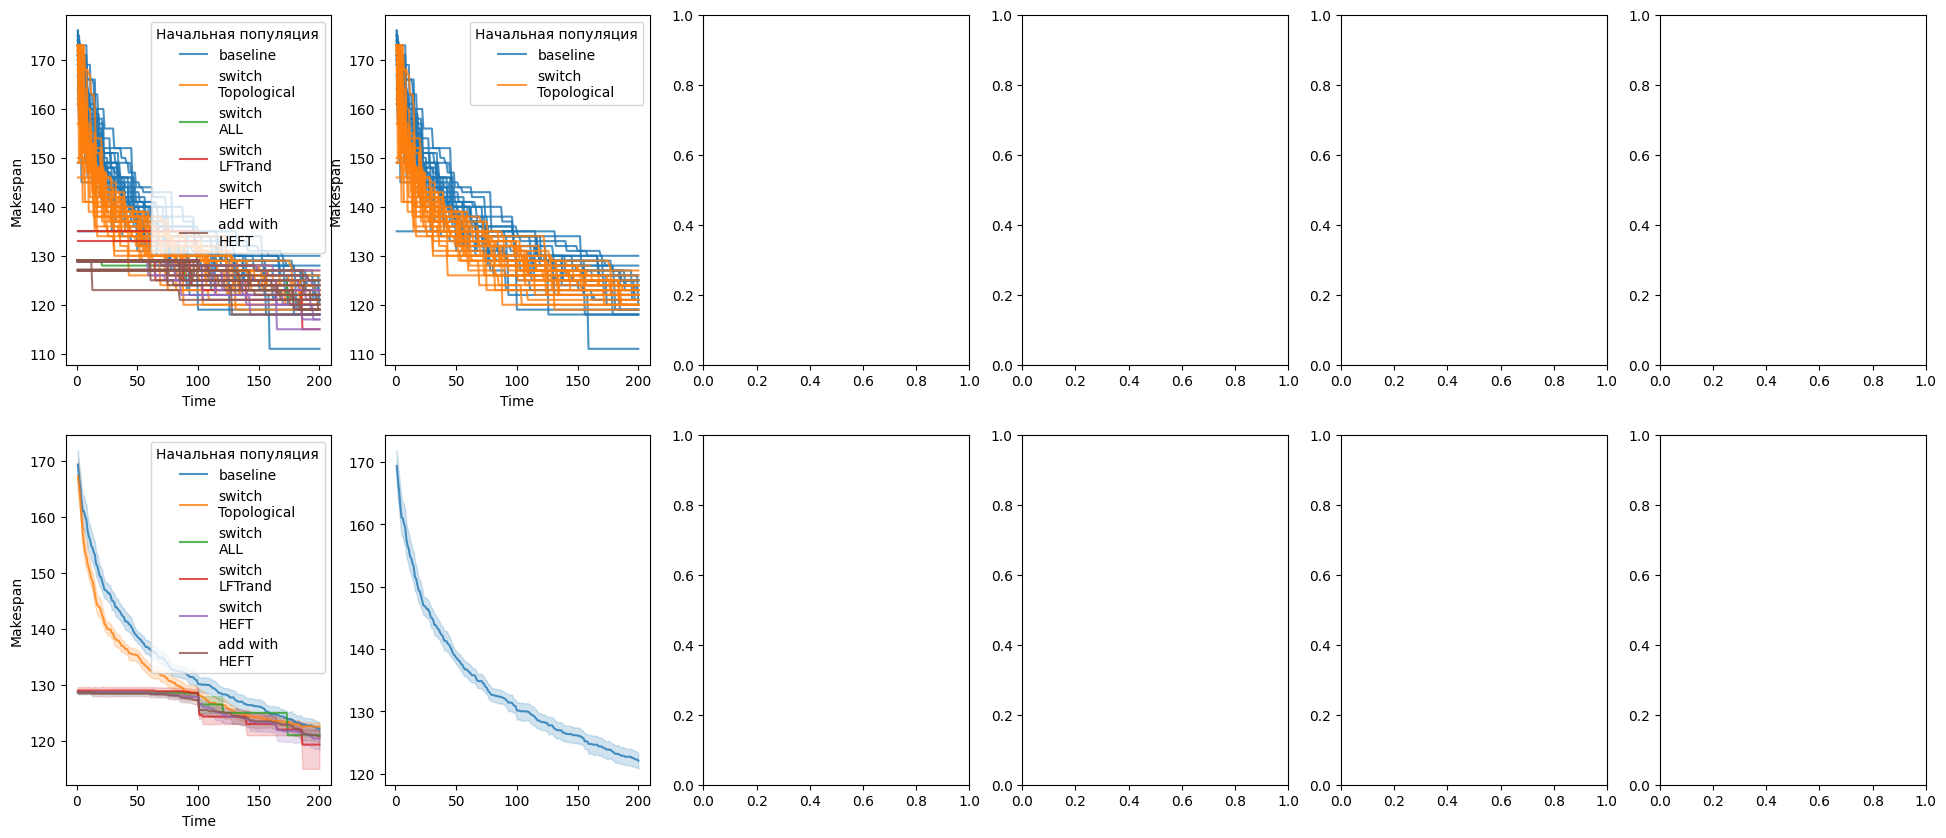

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(*(2, 6), figsize=(24, 10), sharey=False)
axes = axes.flatten()
i = 0


run = 'final_j100.csv'
df = pd.read_csv(os.path.join('Experiments/Runs', run))

name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
}


df['Начальная популяция'] = df['Algorithm'].map(name_map)

plot_iter(df, axes[i],  'Начальная популяция')
plot_smooth_iter(df, axes[i+6], 'Начальная популяция')

i += 1
for algo in df[df.Algorithm != 'genetic']['Algorithm'].unique():
    print(algo)
    mode_df = df[df.Algorithm.isin([algo, 'genetic'])]
    plot_iter(mode_df, axes[i], 'Начальная популяция')
    plot_smooth_iter(mode_df, axes[i+6], 'Начальная популяция')
    i += 1
    
plt.tight_layout()

In [ ]:
import numpy as np
from scipy.stats import t
run = 'final_j50.csv'
df = pd.read_csv(os.path.join('Experiments/Runs', run))

name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
}
df['Начальная популяция'] = df['Algorithm'].map(name_map)

res = (
   df.sort_values(['Начальная популяция', 'run','Time'])\
    .groupby(['Начальная популяция', 'run'])\
    .tail(1)\
    .groupby('Начальная популяция')['Makespan']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.1
res['se'] = res['std'] / np.sqrt(res['count'])
res['t_crit'] = t.ppf(1 - alpha/2, df=res['count'] - 1)
res['ci_low'] = round(res['mean'] - res['t_crit'] * res['se'],2)
res['ci_high'] = round(res['mean'] + res['t_crit'] * res['se'],1)

res.loc[index]



,mean,std,count,se,t_crit,ci_low,ci_high
Начальная популяция,,,,,,,
baseline,92.666667,1.899788,30,0.346852,1.699127,92.08,93.3
add with\nHEFT,92.133333,2.046584,30,0.373653,1.699127,91.50,92.8
switch\nTopological,93.666667,2.056668,30,0.375495,1.699127,93.03,94.3
switch\nLFTrand,95.033333,3.727654,30,0.680573,1.699127,93.88,96.2
switch\nHEFT,91.833333,2.052473,30,0.374729,1.699127,91.20,92.5
switch\nALL,100.566667,3.202190,30,0.584637,1.699127,99.57,101.6


In [ ]:
import numpy as np
from scipy.stats import t
run = 'final_j30.csv'
df = pd.read_csv(os.path.join('Experiments/Runs', run))

name_map = {
    'genetic': 'baseline',
    'combined_models_switch_Topological': 'switch\nTopological',
    'combined_models_switch_ALL': 'switch\nALL',
    'combined_models_switch_LFTrand': 'switch\nLFTrand',
    'combined_models_switch_HEFT': 'switch\nHEFT',
    'combined_models_add_with_HEFT': 'add with\nHEFT',
}
df['Начальная популяция'] = df['Algorithm'].map(name_map)

res = (
   df.sort_values(['Начальная популяция', 'run','Time'])\
    .groupby(['Начальная популяция', 'run'])\
    .tail(1)\
    .groupby('Начальная популяция')['Makespan']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.1
res['se'] = res['std'] / np.sqrt(res['count'])
res['t_crit'] = t.ppf(1 - alpha/2, df=res['count'] - 1)
res['ci_low'] = round(res['mean'] - res['t_crit'] * res['se'],2)
res['ci_high'] = round(res['mean'] + res['t_crit'] * res['se'],1)

res.loc[index]



,mean,std,count,se,t_crit,ci_low,ci_high
Начальная популяция,,,,,,,
baseline,139.600000,2.554239,30,0.466338,1.699127,138.81,140.4
add with\nHEFT,137.766667,2.908766,30,0.531066,1.699127,136.86,138.7
switch\nTopological,140.000000,2.212815,30,0.404003,1.699127,139.31,140.7
switch\nLFTrand,140.333333,3.603957,30,0.657990,1.699127,139.22,141.5
switch\nHEFT,137.900000,2.591099,30,0.473068,1.699127,137.10,138.7
switch\nALL,145.433333,2.824564,30,0.515692,1.699127,144.56,146.3


In [ ]:
last_epoch = df.sort_values(['Начальная популяция', 'run','Time'])\
    .groupby(['Начальная популяция', 'run'])\
    .tail(1)

last_epoch.reset_index(inplace=True)
# baseline = last_epoch.query('`Начальная популяция` == "baseline"')['Makespan'].min()

#last_epoch['better'] = np.where( df.query('Time == 200')['Makespan'] < baseline, 1, 0)

last_epoch['gap'] = (pd.merge(
    last_epoch,
    last_epoch.query('`Начальная популяция` == "baseline"')[['run','Makespan']],
    on='run',
    how='left',
    suffixes=('', '_baseline'))\
    .apply(lambda x: (x['Makespan_baseline'] - x['Makespan']) * 100/ x['Makespan_baseline'], axis=1)
 )
#max((x['Makespan_baseline'] - x['Makespan']) / x['Makespan_baseline'], 0)


index = ['baseline', 
        'add with\nHEFT',
         'switch\nTopological', 
         'switch\nLFTrand', 
         'switch\nHEFT',
         'switch\nALL',]

res_gap = (
    last_epoch
      .groupby('Начальная популяция')['gap']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.1
res_gap['se'] = res_gap['std'] / np.sqrt(res['count'])
res_gap['t_crit'] = t.ppf(1 - alpha/2, df=res_gap['count'] - 1)
res_gap['ci_low'] = round(res_gap['mean'] - res_gap['t_crit'] * res_gap['se'],1)
res_gap['ci_high'] = round(res_gap['mean'] + res_gap['t_crit'] * res_gap['se'],1)

res_gap[['mean', 'ci_low', 'ci_high']].loc[index].apply(lambda x: print(str(round(x['mean'],1)) + '\n' + str(x['ci_low']) + '-' + str(x['ci_high'])), axis=1 )

0.0
0.0-0.0
1.3
0.4-2.1
-0.3
-1.1-0.5
-0.5
-1.4-0.3
1.2
0.3-2.1
-4.2
-5.1--3.3


Начальная популяция
baseline               None
add with\nHEFT         None
switch\nTopological    None
switch\nLFTrand        None
switch\nHEFT           None
switch\nALL            None
dtype: object

In [ ]:
last_epoch['better'] = np.where(last_epoch['gap'] > 0, 1, 0)

In [ ]:
last_epoch.groupby('Начальная популяция').agg({'better':'mean'}).loc[index]

,better
Начальная популяция,
baseline,0.000000
add with\nHEFT,0.633333
switch\nTopological,0.400000
switch\nLFTrand,0.433333
switch\nHEFT,0.566667
switch\nALL,0.066667


# Better  and impovement


In [ ]:

res = (
   df.sort_values(['Начальная популяция', 'run','Time'])\
    .groupby(['Начальная популяция', 'run'])\
    .tail(1)\
    .groupby('Начальная популяция')['Makespan']
      .agg(['mean', 'std', 'count'])
)


alpha = 0.1
res['se'] = res['std'] / np.sqrt(res['count'])
res['t_crit'] = t.ppf(1 - alpha/2, df=res['count'] - 1)
res['ci_low'] = round(res['mean'] - res['t_crit'] * res['se'],2)
res['ci_high'] = round(res['mean'] + res['t_crit'] * res['se'],1)


In [ ]:
last_epoch = df.sort_values(['Начальная популяция', 'run','Time'])\
    .groupby(['Начальная популяция', 'run'])\
    .tail(1)

last_epoch.reset_index(inplace=True)

baseline = last_epoch.query('`Начальная популяция` == "baseline"')['Makespan'].min()

last_epoch['better'] = np.where( (last_epoch['Makespan'] < baseline)  & (last_epoch['Начальная популяция'] !='baseline') , 1, 0)

# last_epoch['gap'] = (pd.merge(
#     last_epoch,
#     last_epoch.query('`Начальная популяция` == "baseline"')[['run','Makespan']],
#     on='run',
#     how='left',
#     suffixes=('', '_baseline'))\
#     .apply(lambda x: (x['Makespan_baseline'] - x['Makespan']) * 100/ x['Makespan_baseline'], axis=1))

In [ ]:
last_epoch

,index,Unnamed: 0,Makespan,Time,run,Algorithm,Начальная популяция,better
0,22647,99,129.0,100,1,combined_models_add_with_HEFT,add with\nHEFT,0
1,22847,199,121.0,200,2,combined_models_add_with_HEFT,add with\nHEFT,0
2,23047,199,124.0,200,3,combined_models_add_with_HEFT,add with\nHEFT,0
3,23147,99,129.0,100,4,combined_models_add_with_HEFT,add with\nHEFT,0
4,23247,99,129.0,100,5,combined_models_add_with_HEFT,add with\nHEFT,0
...,...,...,...,...,...,...,...,...
175,11127,199,122.0,200,26,combined_models_switch_Topological,switch\nTopological,0
176,11327,199,123.0,200,27,combined_models_switch_Topological,switch\nTopological,0
177,11527,199,120.0,200,28,combined_models_switch_Topological,switch\nTopological,0
178,11727,199,124.0,200,29,combined_models_switch_Topological,switch\nTopological,0


In [ ]:
last_epoch.query('`Начальная популяция` != "baseline"')['Makespan']

0      129.0
1      121.0
2      124.0
3      129.0
4      129.0
       ...  
175    122.0
176    123.0
177    120.0
178    124.0
179    122.0
Name: Makespan, Length: 150, dtype: float64

In [ ]:
last_epoch.groupby('Algorithm').better.mean()

Algorithm
combined_models_add_with_HEFT         0.0
combined_models_switch_ALL            0.0
combined_models_switch_HEFT           0.0
combined_models_switch_LFTrand        0.0
combined_models_switch_Topological    0.0
genetic                               0.0
Name: better, dtype: float64

In [ ]:
last_epoch['gap'] = (pd.merge(
    last_epoch,
    last_epoch.query('`Начальная популяция` == "baseline"')[['run','Makespan']],
    on='run',
    how='left',
    suffixes=('', '_baseline'))\
    .apply(lambda x: (x['Makespan_baseline'] - x['Makespan']) * 100/ x['Makespan_baseline'], axis=1))

In [ ]:
res_gap = (
    last_epoch
      .groupby('Начальная популяция')['gap']
      .agg(['mean', 'std', 'count'])
)

alpha = 0.1
res_gap['se'] = res_gap['std'] / np.sqrt(res['count'])
res_gap['t_crit'] = t.ppf(1 - alpha/2, df=res_gap['count'] - 1)
res_gap['ci_low'] = round(res_gap['mean'] - res_gap['t_crit'] * res_gap['se'],1)
res_gap['ci_high'] = round(res_gap['mean'] + res_gap['t_crit'] * res_gap['se'],1)

res_gap[['mean', 'ci_low', 'ci_high']].loc[index].apply(lambda x: print(str(round(x['mean'],1)) + '\n' + str(x['ci_low']) + '-' + str(x['ci_high'])), axis=1 )

0.0
0.0-0.0
-2.6
-4.1--1.1
-0.5
-1.6-0.5
-4.9
-6.2--3.7
-2.7
-4.2--1.1
-5.2
-6.3--4.1


Начальная популяция
baseline               None
add with\nHEFT         None
switch\nTopological    None
switch\nLFTrand        None
switch\nHEFT           None
switch\nALL            None
dtype: object